1. Загрузка среды и импорт набора данных.（加载环境和导入数据集）

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

file_path = 'data/iris.data'
column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
df = pd.read_csv(file_path, header=None, names=column_names)

2. Постройте таблицу pairplot.（绘制 pairplot 表格）

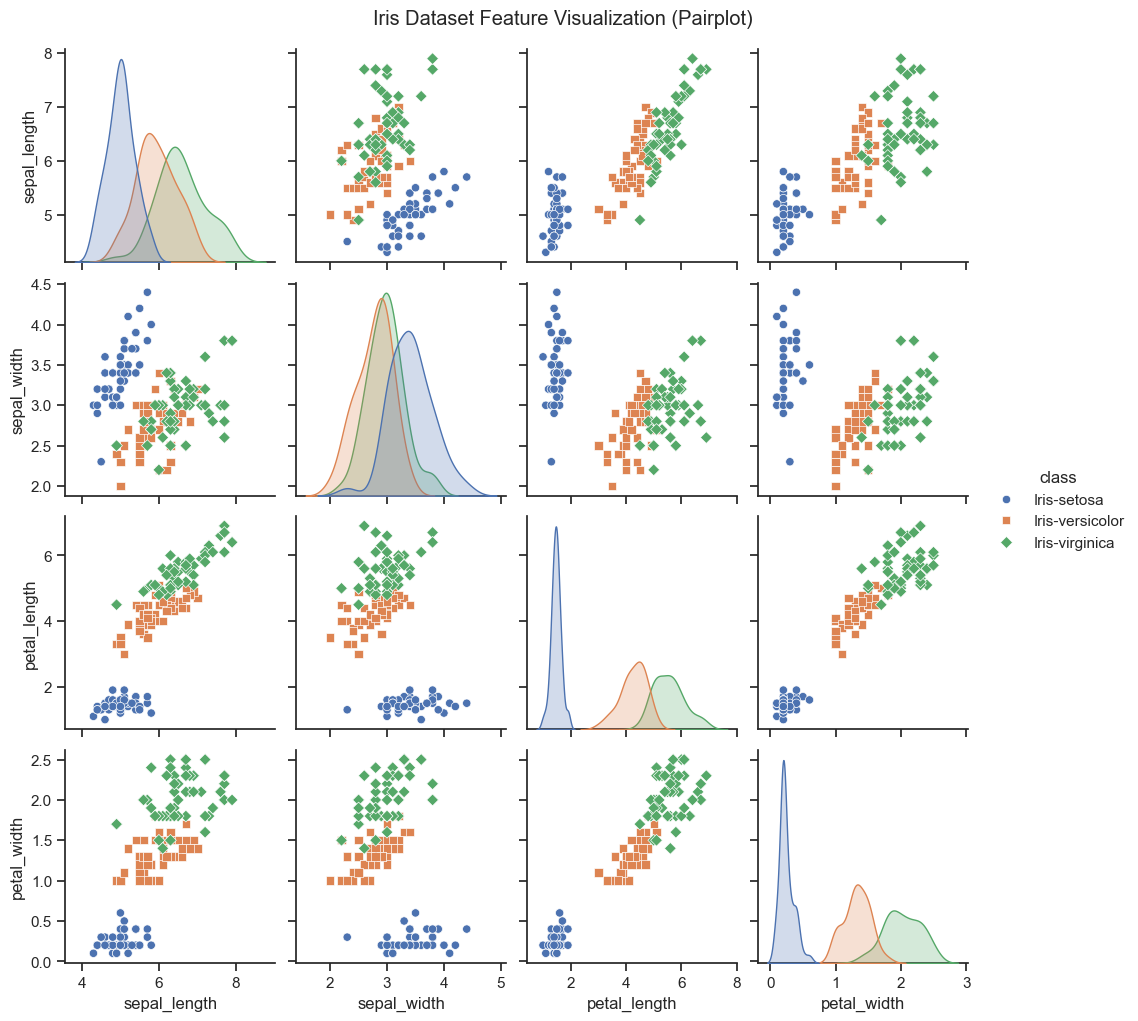

In [20]:
sns.set_theme(style="ticks")
pair_plot = sns.pairplot(df, hue='class', diag_kind="kde", markers=["o", "s", "D"])
pair_plot.fig.suptitle("Iris Dataset Feature Visualization (Pairplot)", y=1.02)

plt.show()


Разделимость категорий: Iris-setosa (горный ирис) демонстрирует чрезвычайно высокую разделимость по всем комбинациям признаков, полностью отделяясь от двух других категорий.

Ключевые признаки: Длина и ширина лепестков являются наиболее эффективными индикаторами для различения разных сортов. Границы распространения трех категорий ирисов относительно четкие по этим двум параметрам.

Корреляция признаков: Существует значительная положительная корреляция между длиной и шириной лепестков, что означает, что с увеличением длины лепестков, как правило, увеличивается и их ширина.

3. Построение модели логистической регрессии. （构建 LogisticRegression（逻辑回归）模型）

In [21]:
df_binary = df[df['class'].isin(['Iris-versicolor', 'Iris-virginica'])].copy()

X = df_binary.drop('class', axis=1)
y = df_binary['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Точность бинарной классификации при логистической регрессии: {accuracy:.4f}")

Точность бинарной классификации при логистической регрессии: 0.9333


В этом эксперименте для бинарной классификации сортов Iris-versicolor и Iris-virginica использовалась логистическая регрессия. Несмотря на некоторое перекрытие пространств признаков этих двух сортов, модель логистической регрессии показала чрезвычайно высокую точность на тестовом наборе данных. Это демонстрирует, что логистическая регрессия, как линейный классификатор, может эффективно находить границу принятия решения в многомерном пространстве признаков для различения этих двух похожих сортов.

4. Переобучение в моделях линейной регрессии.（线性回归模型的过拟合现象。）

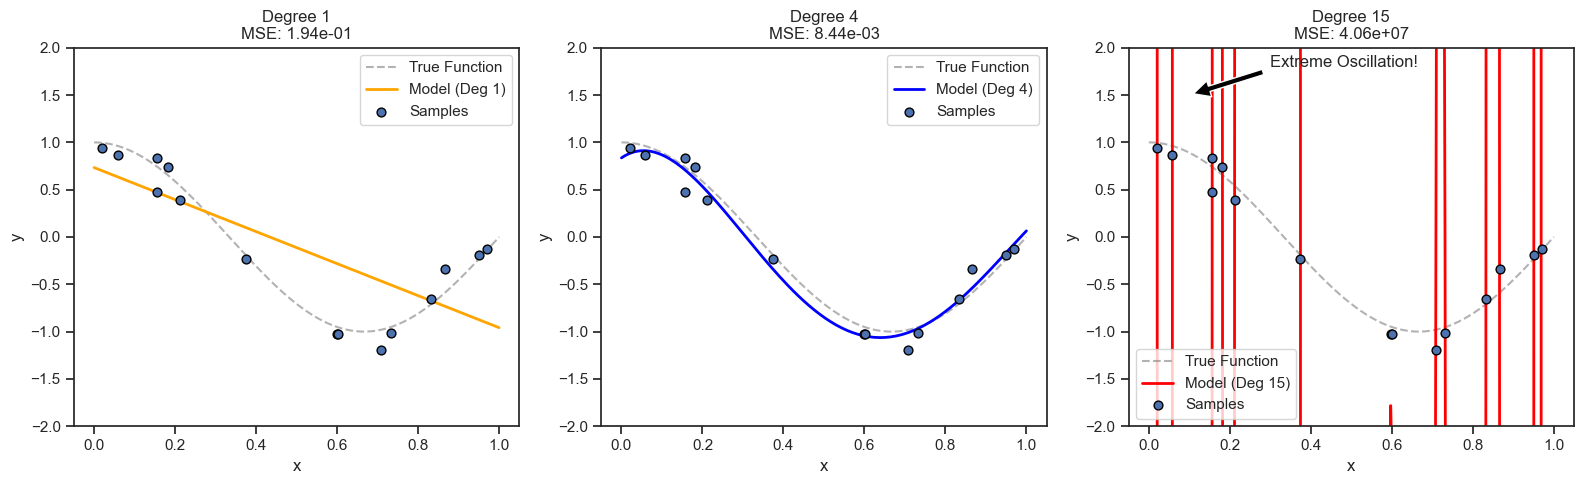

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# 1. 生成数据：减少样本量到 15 个，让过拟合更容易发生
np.random.seed(42)
def true_func(X):
    return np.cos(1.5 * np.pi * X)

n_samples = 15
X = np.sort(np.random.rand(n_samples))
y = true_func(X) + np.random.randn(n_samples) * 0.1 

# 2. 设置三个对比维度：欠拟合、完美平衡、严重过拟合
degrees = [1, 4, 15]

plt.figure(figsize=(16, 5))
X_test_plot = np.linspace(0, 1, 150)[:, np.newaxis]

for i, degree in enumerate(degrees):
    ax = plt.subplot(1, 3, i + 1)
    
    # 在演示演示过拟合时，我们不使用缩放，以展示高次项的不稳定性
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X[:, np.newaxis], y)
    
    # 计算误差
    y_pred_plot = model.predict(X_test_plot)
    mse = mean_squared_error(true_func(X_test_plot), y_pred_plot)
    
    # 绘图
    plt.plot(X_test_plot, true_func(X_test_plot), label="True Function", linestyle='--', color='gray', alpha=0.6)
    plt.plot(X_test_plot, y_pred_plot, label=f"Model (Deg {degree})", color='red' if degree > 10 else ('blue' if degree > 1 else 'orange'), linewidth=2)
    plt.scatter(X, y, edgecolor='black', s=40, label="Samples", zorder=3)
    
    # 设置
    plt.title(f"Degree {degree}\nMSE: {mse:.2e}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.ylim((-2, 2))
    plt.legend(loc="best")
    if i == 2:
        plt.annotate('Extreme Oscillation!', xy=(0.1, 1.5), xytext=(0.3, 1.8),
                     arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.show()

Недостаточное соответствие (степень 1): Модель представляет собой прямую линию, неспособную уловить флуктуации функции косинуса. Модель имеет высокое смещение; она слишком проста и крайне неадекватна в описании как обучающего набора данных, так и истинного паттерна.

Идеальное соответствие (степень 4): Кривая модели плавная и точно соответствует пунктирной линии (истинный паттерн). Она игнорирует случайный шум в выборках и успешно обучается лежащей в основе физической логике. Это указывает на хорошую обобщающую способность с наименьшей среднеквадратичной ошибкой на неизвестных тестовых данных.

Переобучение (степень 15): Модель достигает почти идеальных результатов в каждой точке выборки, но наблюдение за кривой выявляет сильные, бессмысленные колебания между точками выборки (особенно на концах изображения).